# Notebook Instructions

1. If you are new to Jupyter notebooks, please go through this introductory manual <a href='https://quantra.quantinsti.com/quantra-notebook' target="_blank">here</a>.
1. Any changes made in this notebook would be lost after you close the browser window. **You can download the notebook to save your work on your PC.**
1. Before running this notebook on your local PC:<br>
i.  You need to set up a Python environment and the relevant packages on your local PC. To do so, go through the section on "**Run Codes Locally on Your Machine**" in the course.<br>
ii. You need to **download the zip file available in the last unit** of this course. The zip file contains the data files and/or python modules that might be required to run this notebook.

# Local Minima and Maxima

In the previous units, you learnt about the head and shoulders pattern and how it can be identified in price charts. You also know about the ideal trading positions that you can take, whenever you come across a head and shoulders pattern. 

But, how can you possibly identify a head and shoulders pattern, or any chart pattern using Python? 

The key step to identifying patterns in charts is to detect the local minima and maxima points as highlighted in the figure below.

![title](https://d2a032ejo53cab.cloudfront.net/Course/Units/Mcq/UnitContent/txuYCR2f/unnamed-1.png)

Wondering how you can achieve this? Follow through with this notebook and find out!

This notebook is structured as follows:
1. [Import Libraries](#libraries)
2. [Read the Data](#data)
3. [Detect Local Minima Points](#minima)
4. [Visualise the Minima Points](#plot-minima)
5. [Detect Local Maxima Points](#maxima)
6. [Visualise the Minima and Maxima Points](#plot-maxima)
7. [Function to Detect Minima and Maxima Points](#function)
8. [Conclusion and Next Steps](#conclusion)

<a id='libraries'></a>
## Import Libraries

In [1]:
# For data manipulation
import pandas as pd
import numpy as np
from scipy.signal import argrelextrema

# For plotting
import mplfinance as mpf

<a id='data'></a>
## Read the Data

Import the file `spy_daily_1993_2018.csv` using the `read_csv` method of `pandas`. This file has the OHLCV values for the SPY ETF of the daily frequency. This CSV file is available in the zip file of the unit 'Python Codes and Data' in the 'Course Summary' section.

In [2]:
# Import the stock price data
data = pd.read_csv(
    '../data_modules/spy_daily_1993_2018.csv', index_col=0)

# Change the index type to datetime
data.index = pd.to_datetime(data.index)

# Display the data
data.tail()

,Open,High,Low,Close,Volume
Date,,,,,
2018-12-24,224.666298,226.358066,220.183133,220.248917,147311600
2018-12-26,221.780913,231.376968,219.703796,231.376968,218485400
2018-12-27,227.984041,233.360078,224.591113,233.153320,186267300
2018-12-28,234.572501,236.283055,231.630707,232.852539,153100200
2018-12-31,234.553721,235.145843,232.589398,234.892075,144299400


<a id='minima'></a>
## Detect Local Minima Points

We will use an interesting function called the `argrelextrema`from the `scipy` library to detect the local minima and maxima points. With the `argrelextrema` function, you can identify the highest and lowest points within a series of data points. The length of this series can be pre-specified. For eg: specifying 5 will perform a comparison over 5 data points to the left and right. We will store the value of window length under the variable `argrel_window` and pass it to the `argrelextrema` as the `order` parameter.

To learn more about the `argrelextrema` function, you can visit the official documentation page <a href='https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.argrelextrema.html' target="_blank">here</a>.

Syntax:
```python
scipy.signal.argrelextrema(data, comparator, order)
```
Parameters:
* `data`: You can pass either of the `High`, `Low` or `Close` price series as input. 
* `comparator`: Here we specify the type of comparison you wish to perform. For example: `np.less` to check for the lowest points and `np.greater` to check for the highest points.
* `order`: To specify the number of points on each side to use for the comparison, you can set `order = argrel_window`.

Returns:
* The indices of the minima or maxima points in the arrays of integers passed as input.

In [3]:
# Specify a window length
argrel_window = 5

# Prepare the data of the low price series for computing minima points
argrel_data = data.iloc[:-argrel_window]['Low'].values

# Identify the indices of the local minima points
local_min = argrelextrema(argrel_data, np.less, order=argrel_window)[0]

# Display the first 5 indices of the local minima points
print(local_min[:5])

[13 35 46 59 76]


As seen above, we have obtained the integer indices of the minima values and stored them in the variable `local_min`. Using these indices we can check the corresponding low prices to get the minima values.

In [4]:
# Fetch the corresponding local minima values from the data
minima = data.iloc[local_min]['Low']

# Display the first 5 minima points
minima[:5]

Date
1993-02-18    24.685349
1993-03-22    25.815740
1993-04-06    25.526094
1993-04-26    25.073494
1993-05-19    25.399360
Name: Low, dtype: float64

We have finally obtained a list of all the minima points along with their corresponding dates for our data. Now we can move ahead and plot these points to visualise them better.

<a id='plot-minima'></a>
## Visualise the Minima Points

In the following cell, we will use `plot` method from `mplfinance` library for plotting the candlestick chart. The `style` parameter of `plot` function provides the functionality to choose different styles for plotting the pattern. You can refer to  <a href='https://github.com/matplotlib/mplfinance/blob/master/examples/styles.ipynb' target="_blank">this</a> link to know about the same. 

Note: We will take only the data of the most recent 180 candles for plotting so as to avoid any clutter on the chart.

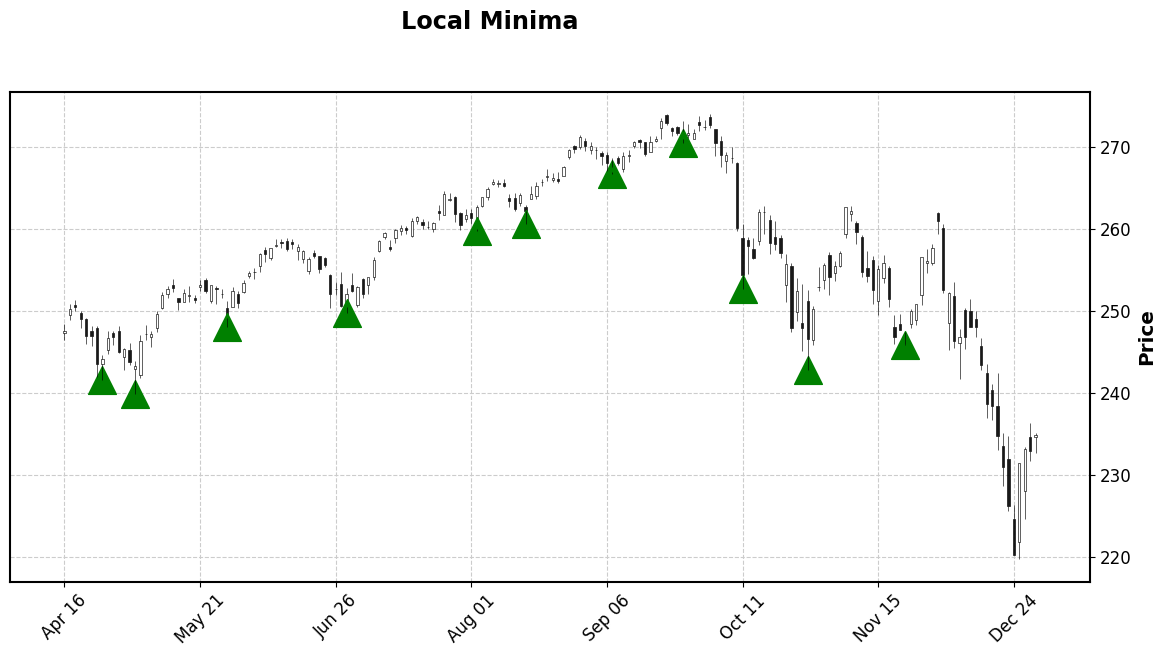

In [5]:
# Prepare data of recent 180 days for plotting
plot_data = data[-180:]

# List of data points that fall under the minima category
min_points = [minima.loc[k]
              if k in minima.index else np.nan for k in plot_data.index]

# Prepare scatter plots for marking the local minima values
apd = mpf.make_addplot(min_points, type='scatter',
                       marker='^', markersize=400, color="green")

# Plot the OHLC data along with the local minima
mpf.plot(plot_data, type='candle', style='classic',
         addplot=apd, title='Local Minima', figsize=(15, 7))

As you may have observed in the above figure, the local minima points have been identified and are highlighted with the help of green markers. Now, let's move forward and also identify the local maxima for the points within our data.

<a id='maxima'></a>
## Detect Local Maxima Points

We will once again make use of the `argrelextrema` function to find the `High` values that correspond to the local maxima. 

To find the local minima, we used the data of the `Low` series and performed the comparison by using `np.less`. However, since local maxima correspond to the swing highs in prices, we will pass the data of the `High` series and use `np.greater` for performing the comparison.

In [6]:
# Prepare the data of the high price series for computing maxima points
argrel_data = data.iloc[:-argrel_window]['High'].values

# Identify and store the local maxima values from the data
local_max = argrelextrema(argrel_data, np.greater, order=argrel_window)[0]
maxima = data.iloc[local_max]['High']
maxima[:5]

Date
1993-02-08    26.018727
1993-03-11    26.433165
1993-03-31    26.340743
1993-04-13    26.159724
1993-05-05    25.924356
Name: High, dtype: float64

<a id='plot-max'></a>
## Visualise the Minima and Maxima Points

We have successfully obtained all of the maxima points from our data. Next, we will perform some basic steps in order to visualise all of the local minima and maxima points over a candlestick chart of the prices for recent data.

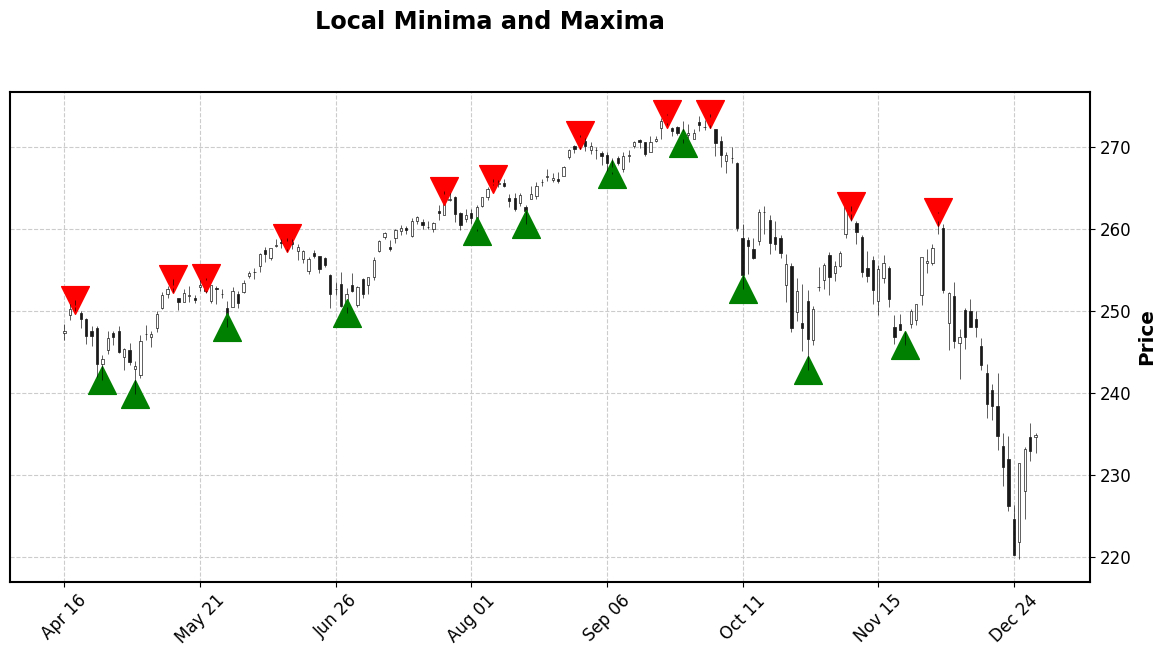

In [7]:
# Prepare data of recent 180 days for plotting
plot_data = data[-180:]

# List of data points that fall under the minima category
min_points = [
    minima.loc[k] if k in minima.index else np.nan for k in plot_data.index]

# List of data points that fall under the maxima category
max_points = [
    maxima.loc[k] if k in maxima.index else np.nan for k in plot_data.index]

# Additional plots for marking the local minima and maxima
apd = [mpf.make_addplot(min_points, type='scatter', color="green", marker='^', markersize=400),
       mpf.make_addplot(max_points, type='scatter', color="red", marker='v', markersize=400)]

# Plot the OHLC data along with the local minima and maxima
mpf.plot(plot_data, type='candle', style='classic',
         addplot=apd, title='Local Minima and Maxima', figsize=(15, 7))

As you can see, both the minima and maxima points have been successfully identified for the price data of SPY over the past few months. In the above code cell, you can increase the value from 180 to view the minima and maxima points over additional data.

<a id='function'></a>
## Function to Detect Minima and Maxima Points

Since identifying the local minima and maxima points is a key step in the process of pattern detection, let us now create a simplified function called `get_min_max` that helps us to identify the local minima and maxima points. Going forward, we can simply call this function and fetch the minima and maxima functions by using fewer lines of code.

The function includes the code that we have already familiarised ourselves with earlier in this notebook. And all we need to do is pass two parameters to this function - the OHLC `data` and the `argrel_window` length for comparison. And the function will return both the local minima as well as the maxima points.

In [8]:
# Create a function to detect local minima and maxima
def get_min_max(data, argrel_window):

    # Use the argrelextrema to compute the local minima and maxima points
    local_min = argrelextrema(
        data.iloc[:-argrel_window]['Low'].values, np.less, order=argrel_window)[0]
    local_max = argrelextrema(
        data.iloc[:-argrel_window]['High'].values, np.greater, order=argrel_window)[0]

    # Store the minima and maxima values in a dataframe
    minima = data.iloc[local_min].Low
    maxima = data.iloc[local_max].High

    # Return dataframes containing minima and maxima values
    return minima, maxima

Let us run the `get_min_max` and see if we obtain both the local minima as well as local maxima points. This time, we will pass `2` which is a shorter length for the `argrel_window` (as compared to `5` which we were using earlier). Doing so will help us fetch more minima and maxima points.

In [9]:
# Implement the get_min_max function and store the results
new_minima, new_maxima = get_min_max(data, 2)
new_minima[:5], new_maxima[:5]

(Date
 1993-02-10    25.676381
 1993-02-18    24.685349
 1993-03-05    25.784485
 1993-03-12    25.838545
 1993-03-17    25.928633
 Name: Low, dtype: float64,
 Date
 1993-02-08    26.018727
 1993-02-11    26.018721
 1993-03-08    26.379097
 1993-03-11    26.433165
 1993-03-18    26.234948
 Name: High, dtype: float64)

<a id='conclusion'></a>
## Conclusion and Next Steps
That was all for now! You have learnt how to identify the local minima and maxima points using Python. In the upcoming Jupyter notebook, we will define certain conditions that will help us scan and detect the presence of the head and shoulders patterns in our dataset.<br><br>